In [40]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np
import sr_fun
importlib.reload(sr_fun)
import pandas as pd
import re

# IOB Fits


Reading from configuration file: conf/iob_0.ini

Reading from configuration file: conf/selection_0.ini

Target: A

All model lengths:
[ 5  6  7  8  9 10 12 14 16 17 18 20 22 24 29]

Equation requested:
((-0.024575) + (1.001780 * ((((((((18.247179 * X2) + 124.669350) + (1318.951782 * X1)) / (sqrt(1 + ((-0.932586) * X5) ^ 2))) + ((29.058573 * X5) + ((-1214.634521) * X1))) + (-126.442230)) / (sqrt(1 + ((((-31.791300) * X5) + (4.723221 * X1)) - (-13.088417)) ^ 2))) - ((((-8826.141602) * X1) + (-805.783447)) / (sqrt(1 + ((-582.973877) * X5) ^ 2))))))

Equation with pars
-1.00178*(-8826.141602*IOB1 - 805.783447)/sqrt(339858.541264411*lam**2 + 1) - 0.024575 + 1.00178*(-1214.634521*IOB1 + 29.058573*lam - 126.44223 + (1318.951782*IOB1 + 18.247179*IOB2 + 124.66935)/sqrt(0.869716647396*lam**2 + 1))/sqrt((4.723221*IOB1 - 31.7913*lam + 13.088417)**2 + 1)

Converted equation:
-c0*(-c1*IOB1 - c2)/sqrt(c3*lam**2 + 1) - c4 + c5*(-c6*IOB1 + c7*lam - c8 + (c9*IOB1 + c10*IOB2 + c11)/sqrt(c12*lam**2 + 1))

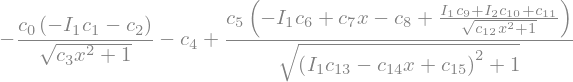


Latex version:
- \frac{c_{0} \left(- I_{1} c_{1} - c_{2}\right)}{\sqrt{c_{3} x^{2} + 1}} - c_{4} + \frac{c_{5} \left(- I_{1} c_{6} + c_{7} x - c_{8} + \frac{I_{1} c_{9} + I_{2} c_{10} + c_{11}}{\sqrt{c_{12} x^{2} + 1}}\right)}{\sqrt{\left(I_{1} c_{13} - c_{14} x + c_{15}\right)^{2} + 1}}

Value at x=1:


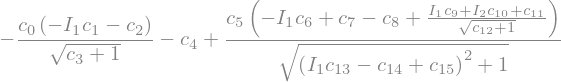


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Reparameterising expression:
Original number of parameters: 18
Temporary global prefix: b, temporary local prefix: d
Old local parameters: ['IOB1', 'IOB2']
Final number of parameters: 10
Of which global: 6 and local: 4
Final values: [-0.0245750000000000, 1.00178, 0.869716647396, 339858.541264411, -31.7913000000000, 29.058573]
Local replacements: {B0: IOB1*c13 + c15, B1: -IOB1*c6 - c8, B2: IOB1*c9 + IOB2*c10 + c11, B3: -c0*(-IOB1*c1 - c2)}


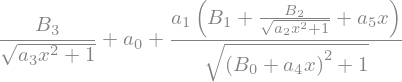


Latex version:
\frac{B_{3}}{\sqrt{a_{3} x^{2} + 1}} + a_{0} + \frac{a_{1} \left(B_{1} + \frac{B_{2}}{\sqrt{a_{2} x^{2} + 1}} + a_{5} x\right)}{\sqrt{\left(B_{0} + a_{4} x\right)^{2} + 1}}

Value at x=1:


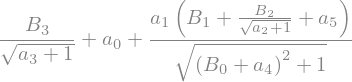

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Generating code...
Saved code to sr_fun.py

Reading from configuration file: conf/iob_0.ini

Reading from configuration file: conf/selection_0.ini

Target: A

RMSE train: 4.450e-01
		2 sigma: -3.0011232176555716 1.8562837400000558
		1 sigma: -1.2174154183356563 0.8431493883269537
		RMSE: 0.445008423284423
		RMAE: 0.23718399953186303
		2 sigma: -0.3175298756522159 0.5604728482157691
		1 sigma: -0.15283574148863877 0.13666157417784844
Median absolute DF/F 0.02068916542288446

RMSE val: 4.607e-01
		2 sigma: -3.3948396856592633 1.751009868093848
		1 sigma: -1.1846097434913847 0.8897793017221568
		RMSE: 0.46072886152517967
		RMAE: 0.2450772161621015
		2 sigma: -0.3160883728687537 0.427846749801708
		1 sigma: -0.15406251256711948 0.14028681687757588
Median absolute DF/F 0.02091321605757379

Re

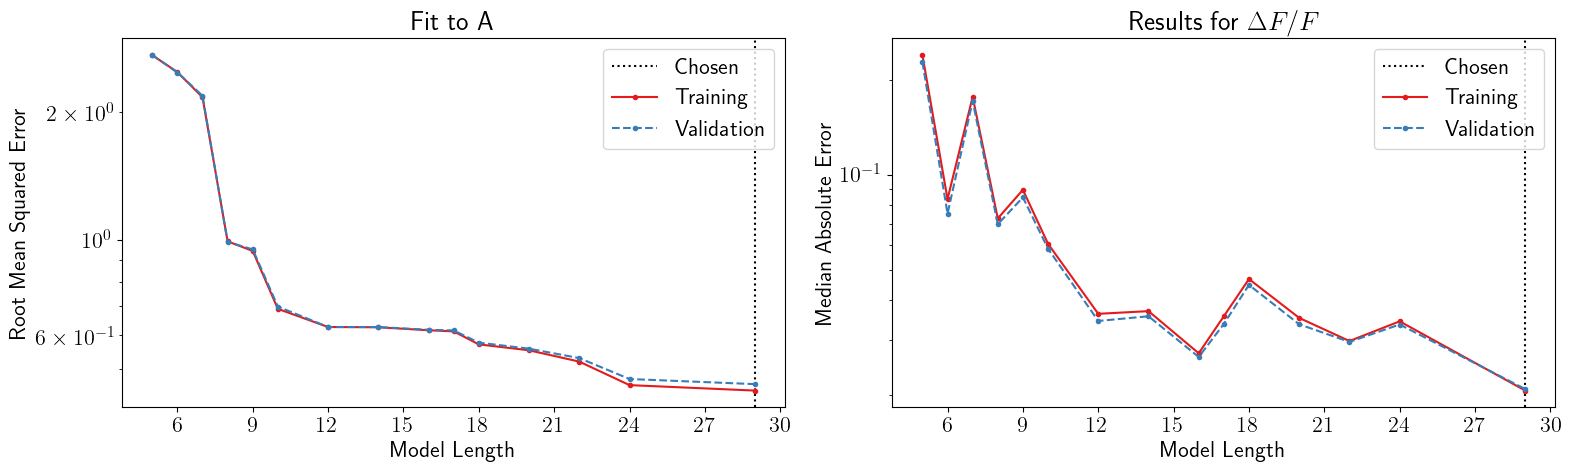

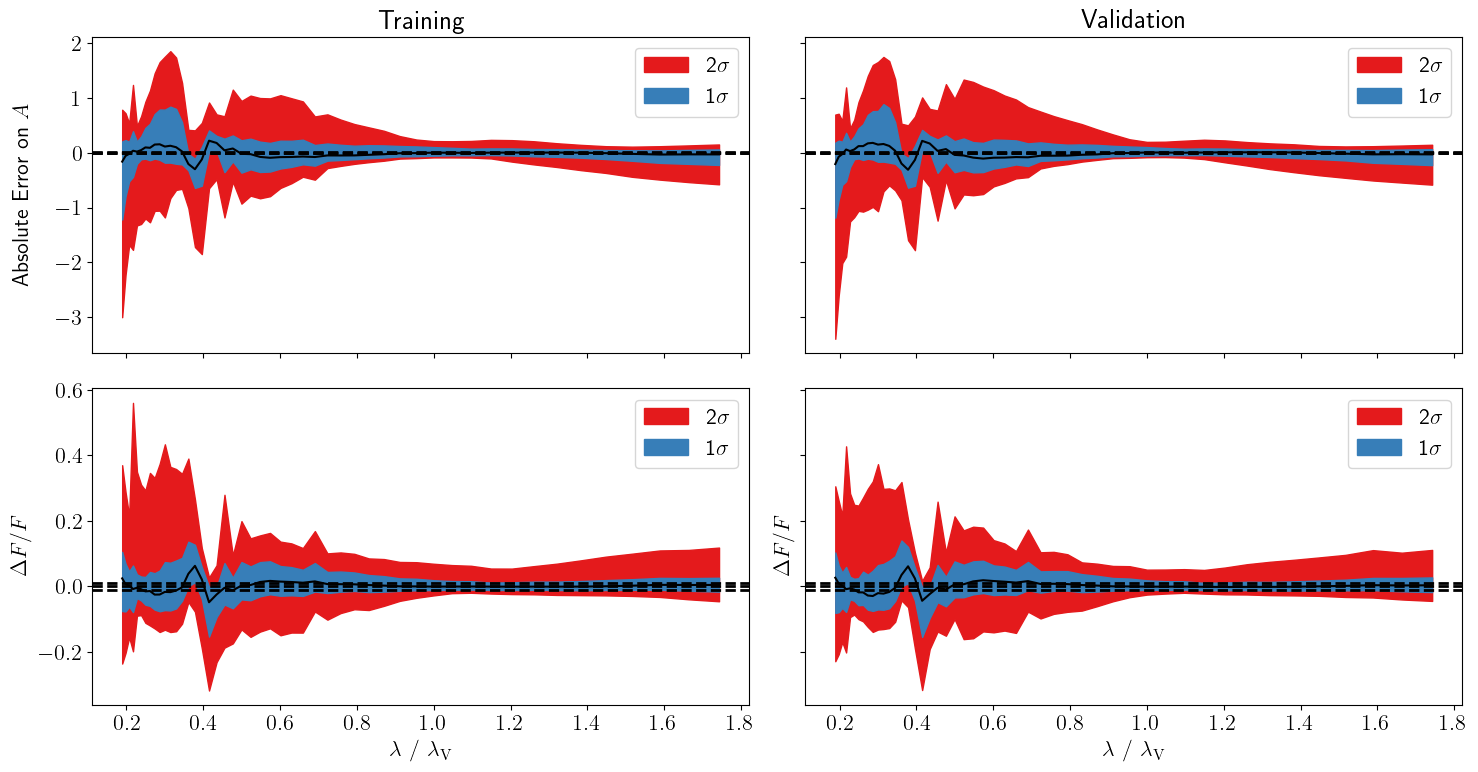

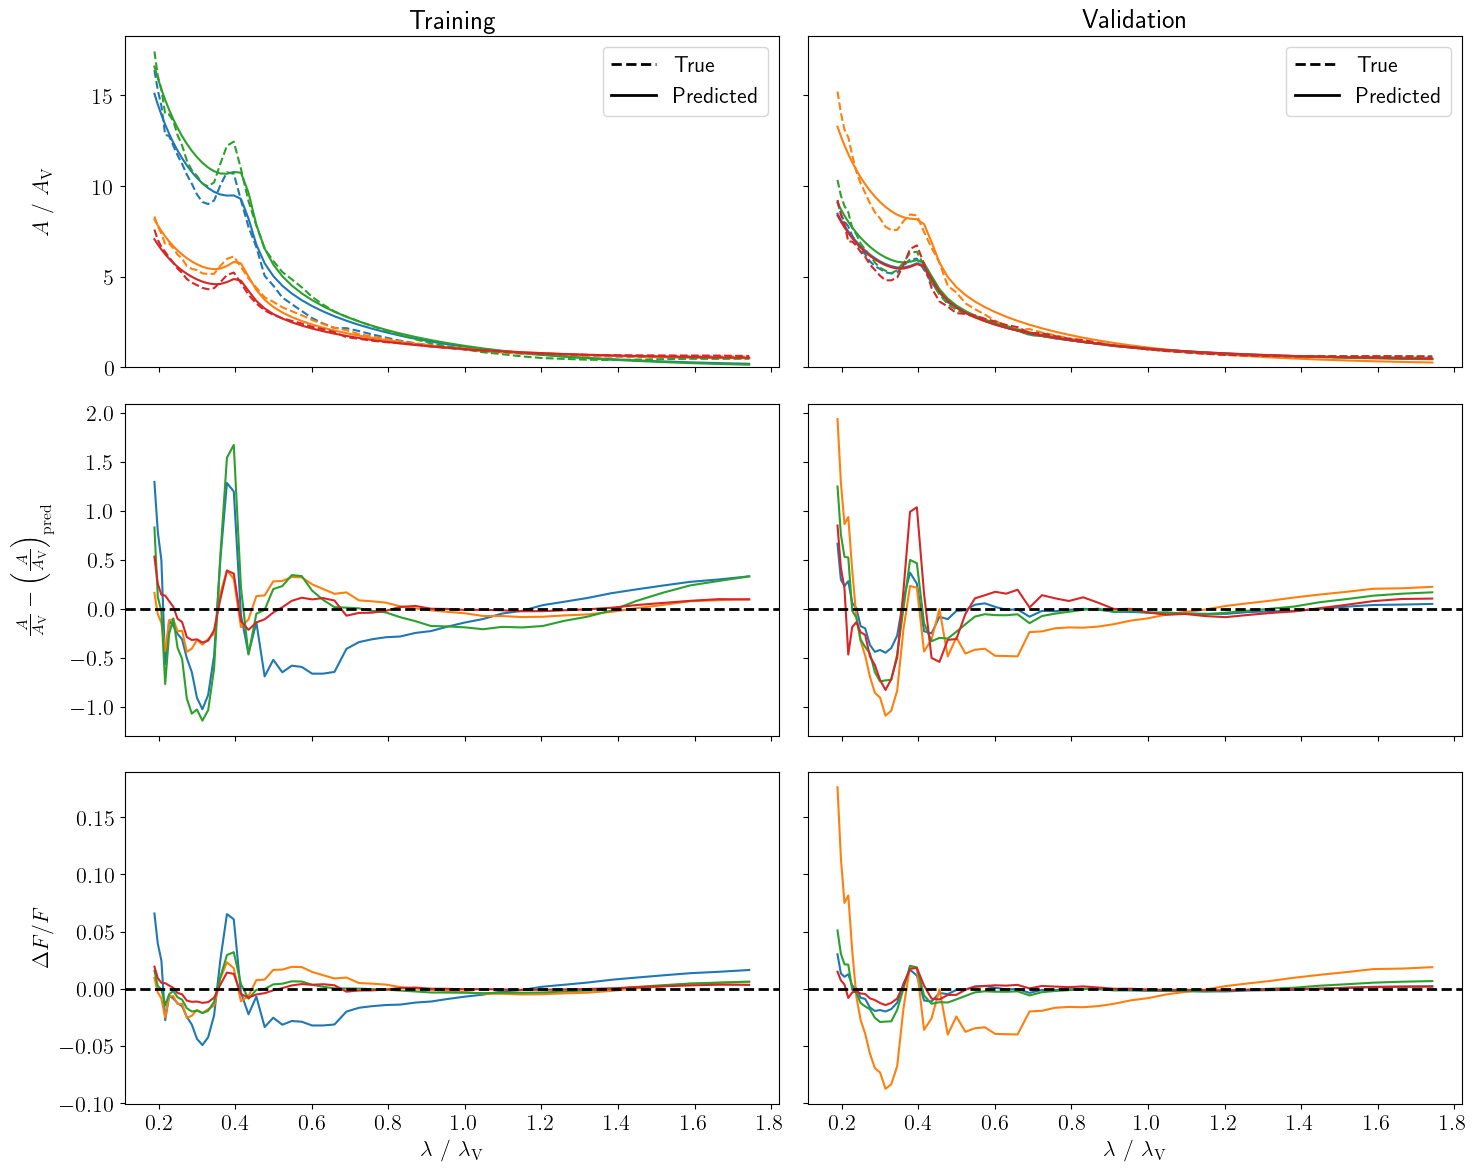

In [41]:
ini_file = 'conf/iob_0.ini'; ilen = None
processing_fun.plot_pareto(ini_file, ilen=ilen, prefix='c')
processing_fun.prediction_plots(ini_file, ilen=ilen, plot_frac_error=False);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=4, offset=0, plot_av_diff=True, plot_dF_F=True);
# processing_fun.compare_to_literature(ini_file, ilen=ilen, which_gals='all', use_optimised=False);

Test output code


Reading from configuration file: conf/iob_6.ini
1.1562242401210138e-06
0.6440796931067786


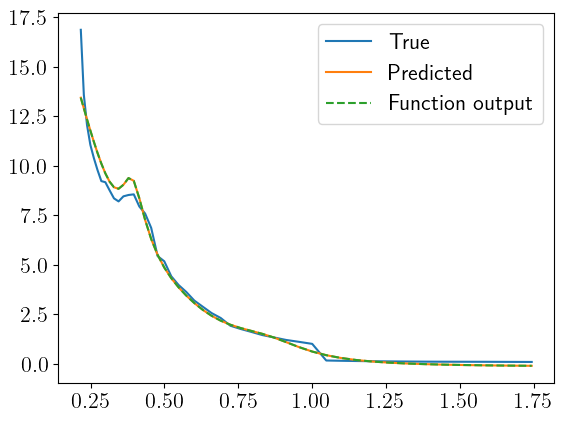

In [70]:
name = 'train'
ini_file = 'conf/iob_6.ini'; ilen = 32

all_data = pd.read_csv('../data/gal_los_iobcomp_attcurve_galprop.dat', sep='\t')
matches = pd.read_csv(f'../symbolic_regression/data/iob_data_10/iob_{name}_galaxy_ids_los.txt', sep='\t',)
matches.rename(columns={"# galaxy_id": "galaxy_id"}, inplace=True)
data_train = all_data.merge(matches, on=['galaxy_id', 'los'], how='inner')
fit_data = pd.read_csv("../data/galaxy_optimization_results.csv")
fit_data.rename(columns={"gal_id": "galaxy_id"}, inplace=True)
data_train = data_train.merge(fit_data, on=['galaxy_id', 'los'], how='inner')

# Get AV
attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
v_index = processing_fun.find_nearest(lam_arr,0.551)

# Get operon data
args = OperonArgs(ini_file)
run_name = f'{args.in_param}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = f'{out_dir}/{run_name}_fun.csv'
df = pd.read_csv(fname, delimiter=';')
if ilen is None:
    eq_idx = -1
else:
    eq_idx = list(df['Length']).index(ilen)
length = list(df['Length'])[eq_idx]
fname = f'{out_dir}/{run_name}_{name}_{length}.csv'
data = np.loadtxt(fname)
ytrue = data[:,args.npar+1]
ypred = data[:,args.npar+2]
if args.fit_log:
    ypred = 10. ** ypred
    ytrue = 10. ** ytrue
fname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_train_data.txt')
with open(fname, 'r') as f:
    header = f.readline().split()
lam = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])
ypred = ypred.reshape(-1, len(lam))
ytrue = ytrue.reshape(-1, len(lam))

for i in [4]:
    gal_id = matches['galaxy_id'].values[i]
    los = matches['los'].values[i]
    row = data_train[(data_train['galaxy_id'] == gal_id) & (data_train['los'] == los)]
    iob_cols = sorted([col for col in row.columns if re.match(r'IOB\d+', col)])
    IOB = row[iob_cols].values[0]
    B = sr_fun.compute_initial_B(IOB)
    new_pred = sr_fun.compute_Av(lam, *B)

    plt.plot(lam, ytrue[i], label='True')
    plt.plot(lam, ypred[i], label='Predicted')
    plt.plot(lam, new_pred, label='Function output', ls='--')
    plt.legend()

    print(np.sqrt(np.mean((new_pred - ypred[i])**2)))
    print(np.sqrt(np.mean((ypred[i] - ytrue[i])**2)))

# A_err_op = [None] * getattr(args, f'n{name}')
# df_F_op = [None] * getattr(args, f'n{name}')
# for j in range(getattr(args, f'n{name}')):
#     A_err_op[j] = ypred[j*len(lam):(j+1)*len(lam)] - ytrue[j*len(lam):(j+1)*len(lam)]
#     df_F_op[j] = data[j*len(lam):(j+1)*len(lam),args.npar+3]

# # Get AV
# attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
# lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
# v_index = processing_fun.find_nearest(lam_arr,0.551)
# Av_name = attenuation_cols[v_index]
# Av = data_train[Av_name].values



# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


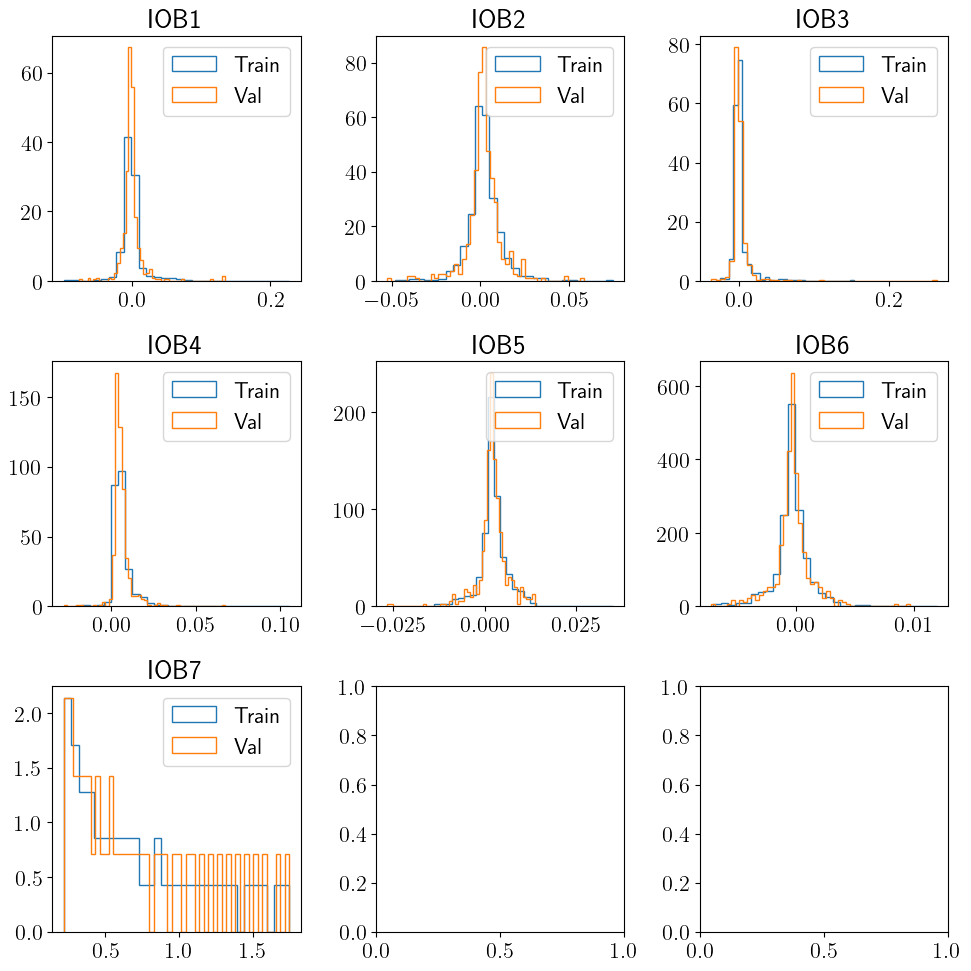

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()